In [98]:
import cv2
import qrcode
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

print("Libraries imported successfully.")

Libraries imported successfully.


In [99]:
BASE_DIR = Path("..")

GENERATED_QR_DIR = BASE_DIR / "sample_data" / "generated_qr"

INPUT_IMAGE_DIR = BASE_DIR / "sample_data" / "input_images"
OUTPUT_DIR = BASE_DIR / "app" / "outputs"

GENERATED_QR_DIR.mkdir(parents=True, exist_ok=True)
INPUT_IMAGE_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

GENERATED_QR_PATH = GENERATED_QR_DIR / "generated_qr.png"

print("Generated QR directory:", GENERATED_QR_DIR)
print("Input image directory:", INPUT_IMAGE_DIR)
print("Output directory:", OUTPUT_DIR)

Generated QR directory: ../sample_data/generated_qr
Input image directory: ../sample_data/input_images
Output directory: ../app/outputs


In [100]:
data = "https://github.com/SajjadHossainSoykot"

qr = qrcode.QRCode(
    version=1,
    error_correction=qrcode.constants.ERROR_CORRECT_H,
    box_size=10,
    border=4,
)

qr.add_data(data)
qr.make(fit=True)

qr_image = qr.make_image(
    fill_color="black",
    back_color="white"
)

qr_image.save(GENERATED_QR_PATH)

print("QR code generated successfully.")
print("Saved at:", GENERATED_QR_PATH)

QR code generated successfully.
Saved at: ../sample_data/generated_qr/generated_qr.png


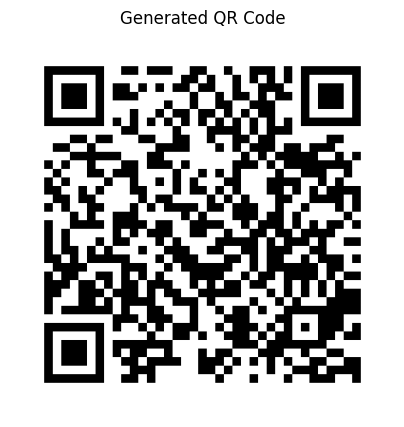

In [101]:
img = Image.open(GENERATED_QR_PATH)

plt.figure(figsize=(5, 5))
plt.imshow(img, cmap="gray")
plt.title("Generated QR Code")
plt.axis("off")
plt.show()

In [102]:
# Read generated QR image using OpenCV

GENERATED_QR_PATH = GENERATED_QR_DIR / "generated_qr.png"
qr_cv_image = cv2.imread(str(GENERATED_QR_PATH))

# INPUT_IMAGE_PATH = INPUT_IMAGE_DIR / "invalid_qr.png"
# qr_cv_image = cv2.imread(str(INPUT_IMAGE_PATH))

if qr_cv_image is None:
    print("Could not read QR image.")
else:
    print("QR image loaded successfully.")
    print("Image shape:", qr_cv_image.shape)

QR image loaded successfully.
Image shape: (450, 450, 3)


In [103]:
# Decode QR code using OpenCV QRCodeDetector

detector = cv2.QRCodeDetector()

decoded_data, bbox, straight_qrcode = detector.detectAndDecode(qr_cv_image)

if decoded_data:
    print("QR code detected successfully.")
    print("Decoded data:")
    print(decoded_data)
else:
    print("No QR code detected.")

QR code detected successfully.
Decoded data:
https://github.com/SajjadHossainSoykot


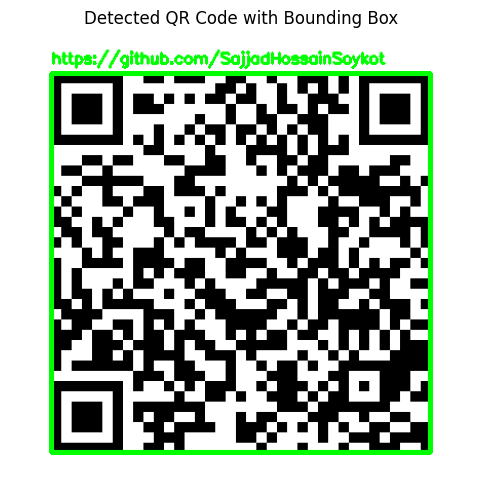

In [104]:
# Draw QR bounding box if detected

display_image = qr_cv_image.copy()

if bbox is not None:
    bbox = bbox.astype(int)

    for i in range(len(bbox[0])):
        point1 = tuple(bbox[0][i])
        point2 = tuple(bbox[0][(i + 1) % len(bbox[0])])
        cv2.line(display_image, point1, point2, (0, 255, 0), 3)

    if decoded_data:
        cv2.putText(
            display_image,
            decoded_data,
            (bbox[0][0][0], bbox[0][0][1] - 10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (0, 255, 0),
            2,
        )

display_rgb = cv2.cvtColor(display_image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6, 6))
plt.imshow(display_rgb)
plt.title("Detected QR Code with Bounding Box")
plt.axis("off")
plt.show()

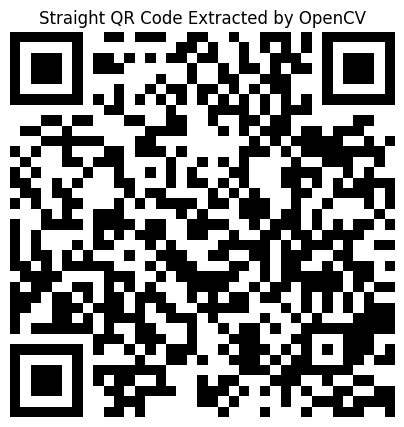

In [105]:
# Show straight QR code returned by OpenCV

if straight_qrcode is not None:
    plt.figure(figsize=(5, 5))
    plt.imshow(straight_qrcode, cmap="gray")
    plt.title("Straight QR Code Extracted by OpenCV")
    plt.axis("off")
    plt.show()
else:
    print("No straight QR output available.")

In [106]:
def preprocess_qr_image(image_path):
    image = cv2.imread(str(image_path))

    if image is None:
        raise ValueError("Could not read image.")

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    contrast = cv2.equalizeHist(gray)

    blur = cv2.GaussianBlur(contrast, (3, 3), 0)

    _, threshold = cv2.threshold(
        blur,
        0,
        255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    return image, gray, contrast, blur, threshold

In [107]:
original, gray, contrast, blur, threshold = preprocess_qr_image(GENERATED_QR_PATH)

print("Original shape:", original.shape)
print("Grayscale shape:", gray.shape)
print("Threshold shape:", threshold.shape)

Original shape: (450, 450, 3)
Grayscale shape: (450, 450)
Threshold shape: (450, 450)


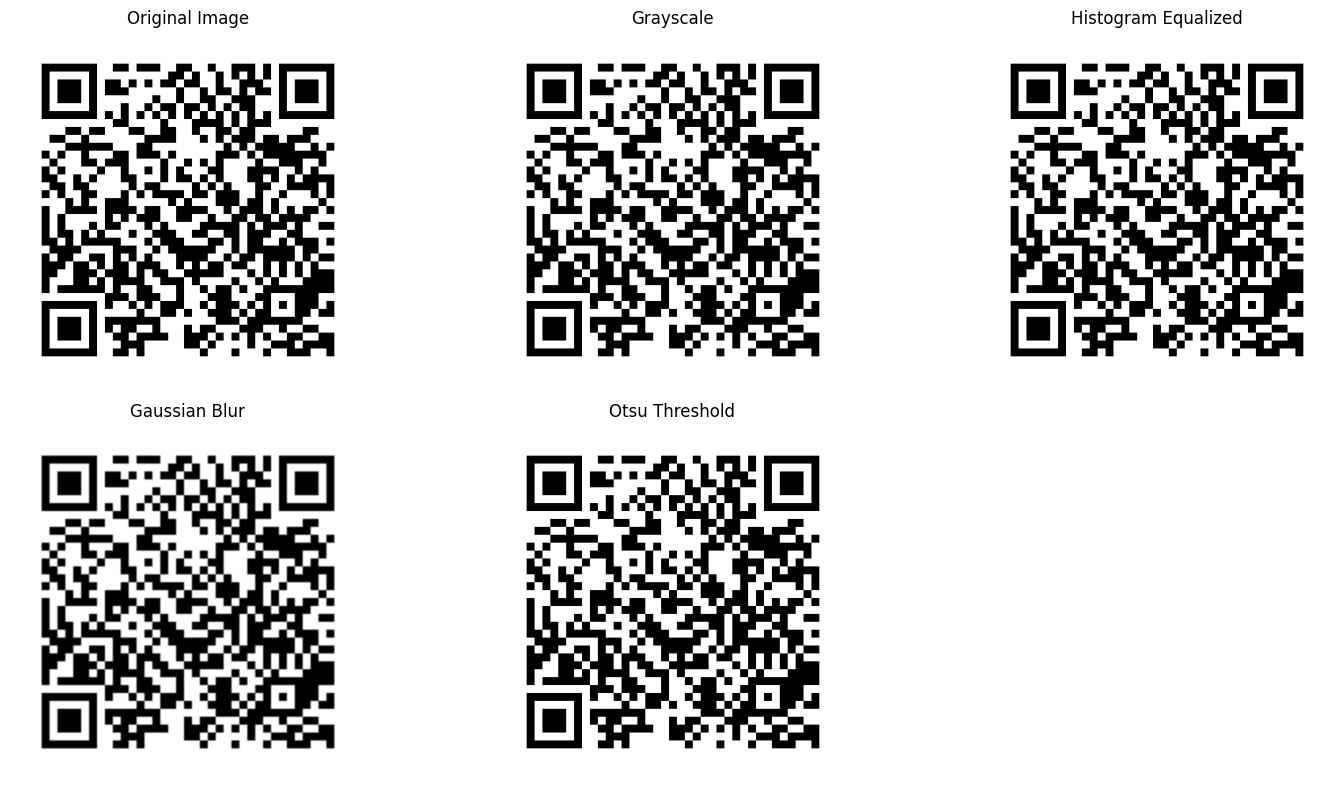

In [108]:
original_rgb = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(15, 8))

plt.subplot(2, 3, 1)
plt.imshow(original_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(gray, cmap="gray")
plt.title("Grayscale")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(contrast, cmap="gray")
plt.title("Histogram Equalized")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(blur, cmap="gray")
plt.title("Gaussian Blur")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(threshold, cmap="gray")
plt.title("Otsu Threshold")
plt.axis("off")

plt.tight_layout()
plt.show()

In [109]:
detector = cv2.QRCodeDetector()

decoded_original, bbox_original, _ = detector.detectAndDecode(original)

if decoded_original:
    print("Decoded from original image:")
    print(decoded_original)
else:
    print("Original image decoding failed. Trying threshold image...")

    decoded_threshold, bbox_threshold, _ = detector.detectAndDecode(threshold)

    if decoded_threshold:
        print("Decoded from preprocessed threshold image:")
        print(decoded_threshold)
    else:
        print("Decoding failed even after preprocessing.")

Decoded from original image:
https://github.com/SajjadHossainSoykot


In [110]:
def order_points(points):
    rect = np.zeros((4, 2), dtype="float32")

    s = points.sum(axis=1)
    diff = np.diff(points, axis=1)

    rect[0] = points[np.argmin(s)]
    rect[2] = points[np.argmax(s)]
    rect[1] = points[np.argmin(diff)]
    rect[3] = points[np.argmax(diff)]

    return rect

In [111]:
def perspective_transform(image, points):
    rect = order_points(points)

    top_left, top_right, bottom_right, bottom_left = rect

    width_top = np.linalg.norm(top_right - top_left)
    width_bottom = np.linalg.norm(bottom_right - bottom_left)
    max_width = int(max(width_top, width_bottom))

    height_right = np.linalg.norm(bottom_right - top_right)
    height_left = np.linalg.norm(bottom_left - top_left)
    max_height = int(max(height_right, height_left))

    destination = np.array(
        [
            [0, 0],
            [max_width - 1, 0],
            [max_width - 1, max_height - 1],
            [0, max_height - 1],
        ],
        dtype="float32",
    )

    matrix = cv2.getPerspectiveTransform(rect, destination)

    warped = cv2.warpPerspective(
        image,
        matrix,
        (max_width, max_height)
    )

    return warped

In [112]:
# image = cv2.imread(str(GENERATED_QR_PATH))
image = cv2.imread(str(Path("sample_data/input_images/business-card-qr.png")))

marked_image = image.copy()

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

blur = cv2.GaussianBlur(gray, (5, 5), 0)

_, threshold = cv2.threshold(
    blur,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

contours, _ = cv2.findContours(
    threshold,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

print("Total contours found:", len(contours))

Total contours found: 1


In [113]:
qr_candidate = None
max_area = 0

for contour in contours:
    area = cv2.contourArea(contour)

    if area < 1000:
        continue

    perimeter = cv2.arcLength(contour, True)

    approx = cv2.approxPolyDP(
        contour,
        0.02 * perimeter,
        True
    )

    if len(approx) == 4:
        x, y, w, h = cv2.boundingRect(approx)
        aspect_ratio = w / float(h)

        if 0.7 <= aspect_ratio <= 1.3:
            if area > max_area:
                max_area = area
                qr_candidate = approx.reshape(4, 2)

if qr_candidate is None:
    print("No QR-like square region found.")
else:
    print("QR-like square region found.")
    print("Corner points:")
    print(qr_candidate)

QR-like square region found.
Corner points:
[[  0   0]
 [  0 699]
 [699 699]
 [699   0]]


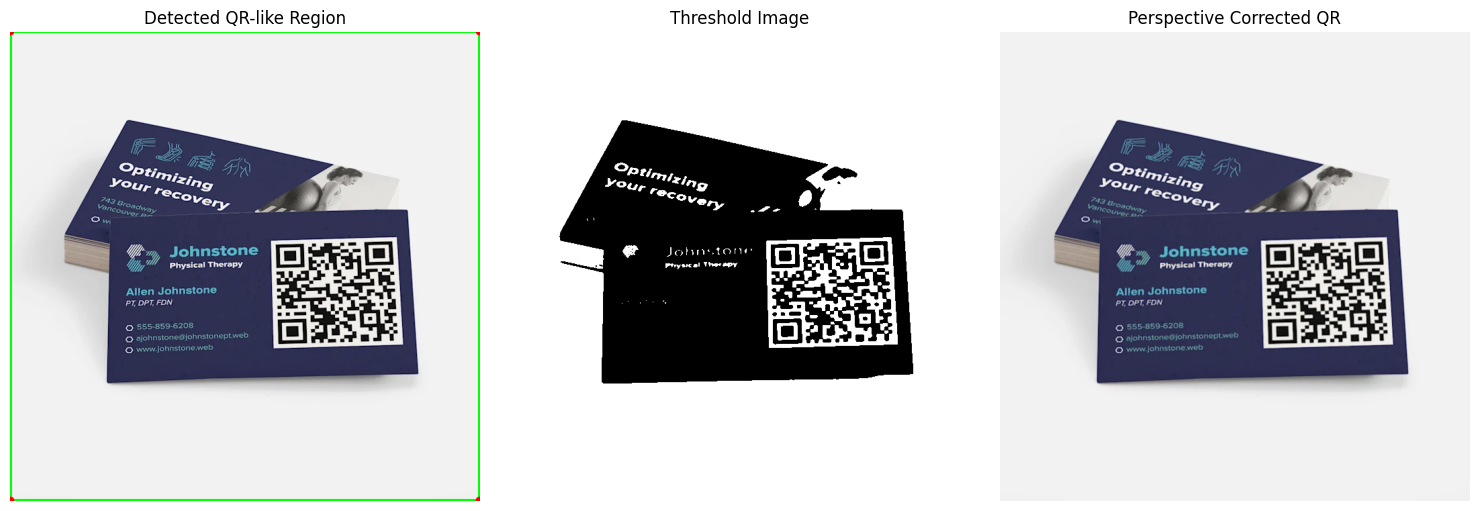

In [114]:
if qr_candidate is not None:
    cv2.polylines(
        marked_image,
        [qr_candidate.astype(int)],
        True,
        (0, 255, 0),
        3
    )

    for point in qr_candidate:
        cv2.circle(
            marked_image,
            tuple(point.astype(int)),
            6,
            (0, 0, 255),
            -1
        )

    warped = perspective_transform(image, qr_candidate)

    marked_rgb = cv2.cvtColor(marked_image, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(marked_rgb)
    plt.title("Detected QR-like Region")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(threshold, cmap="gray")
    plt.title("Threshold Image")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(cv2.cvtColor(warped, cv2.COLOR_BGR2RGB))
    plt.title("Perspective Corrected QR")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

In [115]:
if qr_candidate is not None:
    detector = cv2.QRCodeDetector()

    decoded_warped, bbox_warped, _ = detector.detectAndDecode(warped)

    if decoded_warped:
        print("Decoded from perspective-corrected QR:")
        print(decoded_warped)
    else:
        print("Perspective correction done, but decoding failed.")

Decoded from perspective-corrected QR:
http://www.vistaprint.com/qrcode
